In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
import os
import random
import hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import  (
    accuracy_score,
    f1_score,
    cohen_kappa_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("Tensorflow vesion: ", tf.__version__)
print("GPU devives: ", tf.config.list_physical_devices("GPU"))


Tensorflow vesion:  2.20.0
GPU devives:  [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Random seed fixed at: ", SEED)

Random seed fixed at:  42


In [4]:
ROOT_DIR = Path("/content/drive/MyDrive/Digital_Knee_X_ray_Images")

DATASET_I_DR = ROOT_DIR / "MedicalExpert-I"
DATASET_II_DR = ROOT_DIR / "MedicalExpert-II"

OUTPUT_DIR = Path("/content/drive/MyDrive/MedicalExpert_Seminar_Outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = [
    "0Normal",
    "1Doubtful",
    "2Mild",
    "3Moderate",
    "4Severe"
]

CLASS_DISPLAY_NAMES = [
    "KL 0 - Normal",
    "KL 1 - Doubtful",
    "KL 2 - Mild",
    "KL 3 - Moderate",
    "KL 4 - Severe"
]

IMG_SIZE = (224,244)
BATCH_SIZE = 32
EPOCHS = 25
LEARNING_RATE = 0.001
NUM_CLASSES = len(CLASS_NAMES)

print("MedicalExpert-I exists: ", DATASET_I_DR.exists())
print("MedicalExpert-II exists: ", DATASET_II_DR.exists())
print("Output directory: ", OUTPUT_DIR)


MedicalExpert-I exists:  True
MedicalExpert-II exists:  True
Output directory:  /content/drive/MyDrive/MedicalExpert_Seminar_Outputs


In [5]:
# Hàm đọc dữ liệu từ thư mục
def read_dataset(dataset_dir: Path, dataset_name: str) -> pd.DataFrame:
  records = []
  for label, class_name in enumerate(CLASS_NAMES):
    class_dir = dataset_dir / class_name

    if not class_dir.exists():
      raise FileNotFoundError(f"Không tìm thấy thư mục lớp: {class_dir}")

    image_paths = []
    for extension in ["*.png", "*.jpg", "*.jpeg", "*.PNG", "*.JPG", "*.JPEG"]:
      image_paths.extend(class_dir.glob(extension))

    for image_path in sorted(image_paths):
      records.append({
          "filepath": str(image_path),
          "filename": image_path.name,
          "label": label,
          "class_name": class_name,
          "dataset": dataset_name
      })
  return pd.DataFrame(records)

df_i = read_dataset(DATASET_I_DR, "MedicalExpert-I")
df_ii = read_dataset(DATASET_II_DR, "MedicalExpert-II")

df_all = pd.concat([df_i, df_ii], ignore_index=True)

print("MedicalExpert-I: ", len(df_i))
print("MedicalExpert-II: ", len(df_ii))
print("Total: ", len(df_all))

display(df_all.head())

MedicalExpert-I:  1650
MedicalExpert-II:  1650
Total:  3300


,filepath,filename,label,class_name,dataset
0,/content/drive/MyDrive/Digital_Knee_X_ray_Imag...,NormalG0 (1).png,0,0Normal,MedicalExpert-I
1,/content/drive/MyDrive/Digital_Knee_X_ray_Imag...,NormalG0 (10).png,0,0Normal,MedicalExpert-I
2,/content/drive/MyDrive/Digital_Knee_X_ray_Imag...,NormalG0 (100).png,0,0Normal,MedicalExpert-I
3,/content/drive/MyDrive/Digital_Knee_X_ray_Imag...,NormalG0 (101).png,0,0Normal,MedicalExpert-I
4,/content/drive/MyDrive/Digital_Knee_X_ray_Imag...,NormalG0 (102).png,0,0Normal,MedicalExpert-I


In [6]:
# Thống kê số ảnh theo lớp

distribution = pd.crosstab(
    df_all["class_name"],
    df_all["dataset"]
).reindex(CLASS_NAMES)

distribution["Total"] = distribution.sum(axis=1)
distribution["Meaning"] = CLASS_DISPLAY_NAMES

display(distribution)

dataset,MedicalExpert-I,MedicalExpert-II,Total,Meaning
class_name,,,,
0Normal,514,503,1017,KL 0 - Normal
1Doubtful,477,488,965,KL 1 - Doubtful
2Mild,232,232,464,KL 2 - Mild
3Moderate,221,221,442,KL 3 - Moderate
4Severe,206,206,412,KL 4 - Severe


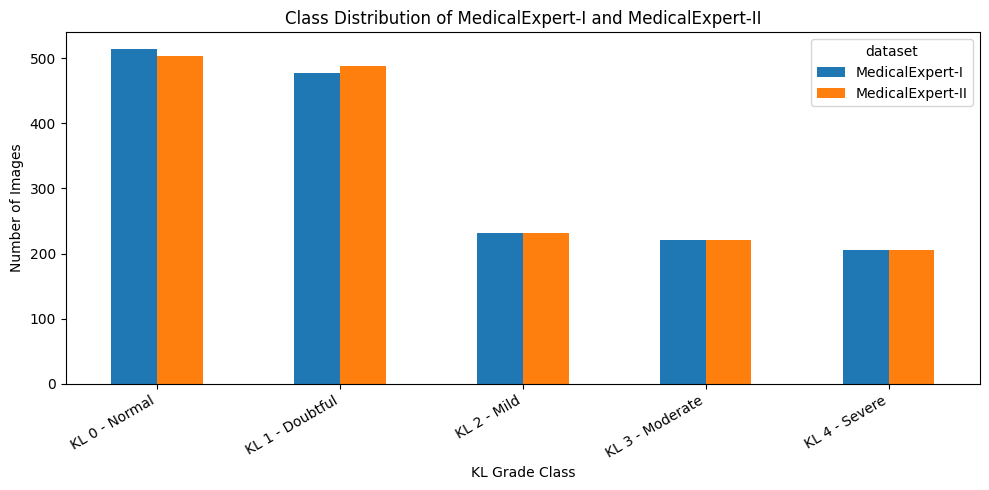

Save to:  /content/drive/MyDrive/MedicalExpert_Seminar_Outputs/dataset_class_distribution.png


In [7]:
# Vẽ biểu đồ phân bố dữ liệu
plot_df = (
    df_all.groupby(["dataset", "class_name"])
    .size()
    .reset_index(name="number_of_images")
)

pivot_df = plot_df.pivot(
    index = "class_name",
    columns = "dataset",
    values = "number_of_images"
).reindex(CLASS_NAMES)

pivot_df.plot(kind="bar", figsize=(10, 5))

plt.title("Class Distribution of MedicalExpert-I and MedicalExpert-II")
plt.xlabel("KL Grade Class")
plt.ylabel("Number of Images")
plt.xticks(
    ticks=range(NUM_CLASSES),
    labels=CLASS_DISPLAY_NAMES,
    rotation=30,
    ha="right"
)

plt.tight_layout()

distribution_image_path = OUTPUT_DIR / "dataset_class_distribution.png"
plt.savefig(distribution_image_path, dpi = 300, bbox_inches="tight")
plt.show()

print("Save to: ", distribution_image_path)

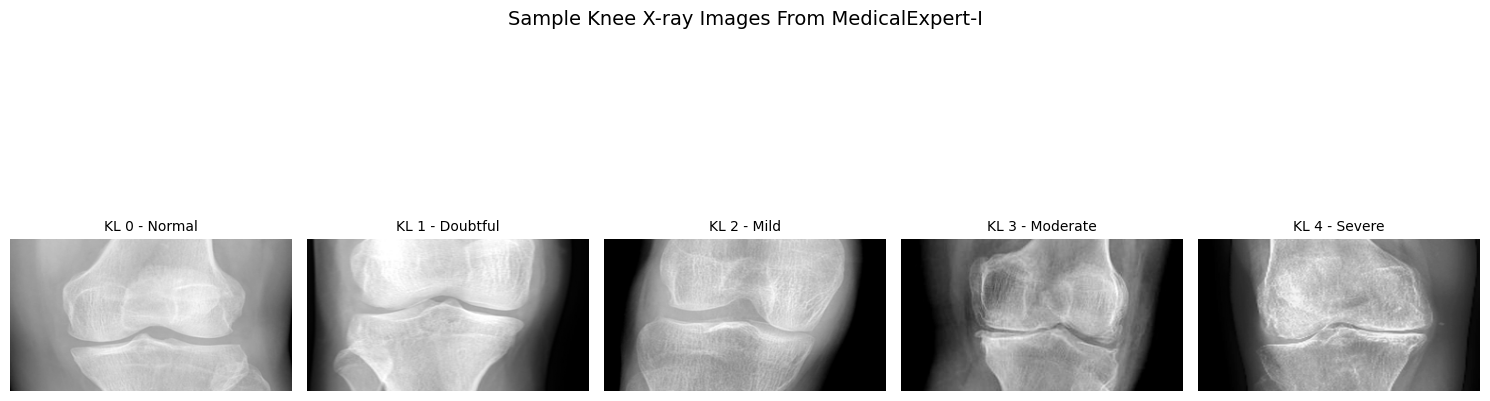

Save to:  /content/drive/MyDrive/MedicalExpert_Seminar_Outputs/sample_image_medicalexpert-i.png


In [8]:
# Hiển thị hình ảnh mẫu của từng lớp
plt.figure(figsize=(15, 6))

for label, class_name in enumerate(CLASS_NAMES):
  sample_path = df_i[df_i['label'] == label]["filepath"].iloc[0]

  image = tf.keras.utils.load_img(
      sample_path,
      color_mode = "grayscale"
  )

  plt.subplot(1, NUM_CLASSES, label + 1)
  plt.imshow(image, cmap="gray")
  plt.title(CLASS_DISPLAY_NAMES[label], fontsize = 10)
  plt.axis("off")

plt.suptitle("Sample Knee X-ray Images From MedicalExpert-I", fontsize = 14)
plt.tight_layout()

sample_image_path = OUTPUT_DIR / "sample_image_medicalexpert-i.png"
plt.savefig(sample_image_path,dpi = 300, bbox_inches="tight")
plt.show()

print("Save to: ", sample_image_path)

In [9]:
# Kiểm tra trùng filename
duplicate_filenames = set(df_i["filename"]).intersection(set(df_ii["filename"]))

print("Number of duplicate filenames: ", len(duplicate_filenames))

if duplicate_filenames:
  print("Examples: ", list(duplicate_filenames)[:10])

Number of duplicate filenames:  1639
Examples:  ['MildG2 (60).png', 'DoubtfulG1 (226).png', 'ModerateG3 (175).png', 'NormalG0 (126).png', 'DoubtfulG1 (113).png', 'MildG2 (82).png', 'NormalG0 (8).png', 'NormalG0 (162).png', 'DoubtfulG1 (311).png', 'NormalG0 (47).png']


In [10]:
# Kiểm tra ảnh bị trùng hoàn toàn bằng mã hoá MD5
def calculate_md5(filepath: str) -> str:
  md5_hash = hashlib.md5()

  with open(filepath, "rb") as file:
    for chunk in iter(lambda: file.read(4096), b""):
      md5_hash.update(chunk)

  return md5_hash.hexdigest()

df_i = df_i.copy()
df_ii = df_ii.copy()

df_i["hash"] = df_i["filepath"].apply(calculate_md5)
df_ii["hash"] = df_ii["filepath"].apply(calculate_md5)

duplicate_hashes = set(df_i["hash"]).intersection(set(df_ii["hash"]))

print("Number of exact dulicated images: ", len(duplicate_hashes))

Number of exact dulicated images:  1633


In [11]:
# Loại bỏ ảnh trùng khỏi test set
if len(duplicate_hashes) > 0:
  duplicate_test_images = df_ii[df_ii["hash"].isin(duplicate_hashes)]

  print("Removing duplicated images from MedicalExpert-II test set: ")
  display(duplicate_test_images.head())

  test_source_df = df_ii[~df_ii["hash"].isin(duplicate_hashes)].copy()

else:
  test_source_df = df_ii.copy()

print("MedicalExpert-II original size: ", len(df_ii))
print("Test set after exact duplicate removal: ", len(test_source_df))

Removing duplicated images from MedicalExpert-II test set: 


,filepath,filename,label,class_name,dataset,hash
0,/content/drive/MyDrive/Digital_Knee_X_ray_Imag...,NormalG0 (1).png,0,0Normal,MedicalExpert-II,966fb4c02a97c3ffb89f91a98e22437f
1,/content/drive/MyDrive/Digital_Knee_X_ray_Imag...,NormalG0 (10).png,0,0Normal,MedicalExpert-II,1af13c5538c1ab5597db6ad72b61e463
2,/content/drive/MyDrive/Digital_Knee_X_ray_Imag...,NormalG0 (100).png,0,0Normal,MedicalExpert-II,e9305b8cbbd5ccb7cd894762124e803b
3,/content/drive/MyDrive/Digital_Knee_X_ray_Imag...,NormalG0 (101).png,0,0Normal,MedicalExpert-II,dfc4994e51039c9fb4d960c706865c2d
4,/content/drive/MyDrive/Digital_Knee_X_ray_Imag...,NormalG0 (102).png,0,0Normal,MedicalExpert-II,0156aac54417d9c793356c816324016c


MedicalExpert-II original size:  1650
Test set after exact duplicate removal:  0


In [12]:
# Chia MedicalExpert-I thành Train và Validation
train_df, val_df = train_test_split(
    df_i,
    test_size = 0.2,
    stratify = df_i["label"],
    random_state = SEED
)

test_df = test_source_df.copy()

print("Train size: ", len(train_df))
print("Valiadtion size: ", len(val_df))
print("Test size: ", len(test_df))

Train size:  1320
Valiadtion size:  330
Test size:  0


In [13]:
# kiểm tra phân bố sau chia
def cout_class_distribution(dataframe: pd.DataFrame, column_name: str) -> pd.Series:
  return (
      dataframe["class_name"]
      .value_counts()
      .reindex(CLASS_NAMES)
      .fillna(0)
      .astype(int)
      .rename(column_name)
  )

split_distribution = pd.concat([
    cout_class_distribution(train_df, "Train - MedicalExpert-I"),
    cout_class_distribution(val_df, "Validation - MedicalExpert-I"),
    cout_class_distribution(test_df, "Test - MedicalExpert-I")
], axis=1)

split_distribution["Meaning"] = CLASS_DISPLAY_NAMES

display(split_distribution)

,Train - MedicalExpert-I,Validation - MedicalExpert-I,Test - MedicalExpert-I,Meaning
class_name,,,,
0Normal,411,103,0,KL 0 - Normal
1Doubtful,381,96,0,KL 1 - Doubtful
2Mild,186,46,0,KL 2 - Mild
3Moderate,177,44,0,KL 3 - Moderate
4Severe,165,41,0,KL 4 - Severe


In [14]:
#Hàm đọc và tiền xử lý ảnh
AUTOTUNE = tf.data.AUTOTUNE

def load_and_preprogress_image(filepath, label):
  image = tf.io.read_file(filepath)

  #chuyển ảnh
  image = tf.io.decode_image(
      image,
      channels = 3,
      expand_animations = False
  )

  image.set_shape([None, None, 3])

  image = tf.image.resize(image, IMG_SIZE)

  #EfficinetNetB0 của Keras nhận float pixel trong khoảng [0,255]
  image = tf.cast(image, tf.float32)

  return image, label

In [15]:
#Tạo tensorflow dataset
def create_tf_dataset(dataframe: pd.DataFrame, training: bool = False):
  filepaths = dataframe["filepath"].values
  labels = dataframe["label"].values.astype(np.int32)

  dataset = tf.data.Dataset.from_tensor_slices((filepaths, labels))

  if training:
    dataset = dataset.shuffle(
        buffer_size=len(dataframe),
        seed=SEED,
        reshuffle_each_iteration=True
    )

  dataset = dataset.map(
      load_and_preprogress_image,
      num_parallel_calls=AUTOTUNE
  )

  dataset = dataset.batch(BATCH_SIZE)
  dataset = dataset.prefetch(AUTOTUNE)

  return dataset

train_ds = create_tf_dataset(train_df, training=True)
val_ds = create_tf_dataset(val_df, training=False)
test_ds = create_tf_dataset(test_df, training=False)

for images, labels in train_ds.take(1):
  print("Batch images shape: ", images.shape)
  print("Batch labels shape: ", labels.shape)
  print("Minimum pixel value: ", tf.reduce_min(images).numpy())
  print("Maximum pixel value: ", tf.reduce_max(images).numpy())

Batch images shape:  (32, 224, 244, 3)
Batch labels shape:  (32,)
Minimum pixel value:  0.0
Maximum pixel value:  250.25098


In [16]:
#Xử lý mất cân bằng lớp
train_labels = train_df["label"].values

classes = np.unique(train_labels)
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_labels
)

class_weights = {
    int(class_id) : float(weight)
    for class_id, weight in zip(classes, weights)
}

print("Class weights: ")
for class_id, weight in class_weights.items():
  print(f"Class {class_id}: {weight}")

Class weights: 
Class 0: 0.6423357664233577
Class 1: 0.6929133858267716
Class 2: 1.4193548387096775
Class 3: 1.4915254237288136
Class 4: 1.6


In [17]:
#Khai báo tăng cường dữ liệu nhẹ
data_augmentation = keras.Sequential(
    [
        layers.RandomRotation(
            factor = 0.2,
            fill_mode = "nearest",
        ),
        layers.RandomZoom(
            height_factor = (-0.05, 0.05),
            width_factor = (-0.05, 0.05),
            fill_mode = "nearest"
        ),
        layers.RandomTranslation(
            height_factor = 0.03,
            width_factor = 0.03,
            fill_mode = "nearest"
        )
    ],
    name="data_augmentation"
)



In [18]:
#Khởi tạo EfficientNetB0
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE[0],IMG_SIZE[1], 3)
)

#giai đoạn đầu đóng băng backdone
base_model.trainable = False

print("Number of layer in EfficientNetB0:", len(base_model.layers))

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Number of layer in EfficientNetB0: 238


In [19]:
#ghép mô hình phân loại 5 lớp
inputs = keras.Input(
    shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    name="knee_xray_input"
)

x = data_augmentation(inputs)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D(
    name="global_average_pooling"
)(x)

x = layers.Dropout(
    rate=0.3,
    name="dropout"
)(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax",
    name="knee_xray_output"
)(x)

model = keras.Model(
    inputs=inputs,
    outputs=outputs,
    name="EfficientNetB0_MedicalExpert_KL_Classifier"
)

model.summary()


Model: "EfficientNetB0_MedicalExpert_KL_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ knee_xray_input (InputLayer)    │ (None, 224, 244, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 244, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 8, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ knee_xray_output (Dense)        │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,055,976 (15.47 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [20]:
#complice mô hình
model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=LEARNING_RATE
    ),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

In [21]:
#Khai bao callbacks
BEST_MODEL_PATH = OUTPUT_DIR / "best_efficientnetb0_medicalexpert.keras"

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=BEST_MODEL_PATH,
        monitor = "val_loss",
        save_best_only=True,
        mode="min",
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        mode="min",
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-6,
        mode="min",
        verbose=1
    )
]


In [22]:
#Huấn luyện giai đoạn 1
history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=callbacks,
    class_weight=class_weights,
    verbose = 1
)

Epoch 1/25
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.2481 - loss: 1.6346
Epoch 1: val_loss improved from None to 1.36369, saving model to /content/drive/MyDrive/MedicalExpert_Seminar_Outputs/best_efficientnetb0_medicalexpert.keras

Epoch 1: finished saving model to /content/drive/MyDrive/MedicalExpert_Seminar_Outputs/best_efficientnetb0_medicalexpert.keras
42/42 ━━━━━━━━━━━━━━━━━━━━ 30s 343ms/step - accuracy: 0.2841 - loss: 1.5475 - val_accuracy: 0.4182 - val_loss: 1.3637 - learning_rate: 0.0010
Epoch 2/25
41/42 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.3803 - loss: 1.3819
Epoch 2: val_loss improved from 1.36369 to 1.22192, saving model to /content/drive/MyDrive/MedicalExpert_Seminar_Outputs/best_efficientnetb0_medicalexpert.keras

Epoch 2: finished saving model to /content/drive/MyDrive/MedicalExpert_Seminar_Outputs/best_efficientnetb0_medicalexpert.keras
42/42 ━━━━━━━━━━━━━━━━━━━━ 8s 182ms/step - accuracy: 0.4167 - loss: 1.3269 - val_accuracy: 0.5242 - val_loss: 1

In [23]:
#lưu lịch sử training
history_df = pd.DataFrame(history.history)

history_csv_path = OUTPUT_DIR / "training_history.csv"
history_df.to_csv(history_csv_path, index=False, encoding="utf-8-sig")

display(history_df.tail())

print("Save training history to: ", history_csv_path)

,accuracy,loss,val_accuracy,val_loss,learning_rate
7,0.571212,1.052394,0.548485,1.092177,0.00100
8,0.575758,1.054497,0.560606,1.080742,0.00100
9,0.593939,1.040624,0.578788,1.073703,0.00020
10,0.581818,1.026081,0.566667,1.076628,0.00020
11,0.568939,1.040558,0.563636,1.069917,0.00004


Save training history to:  /content/drive/MyDrive/MedicalExpert_Seminar_Outputs/training_history.csv


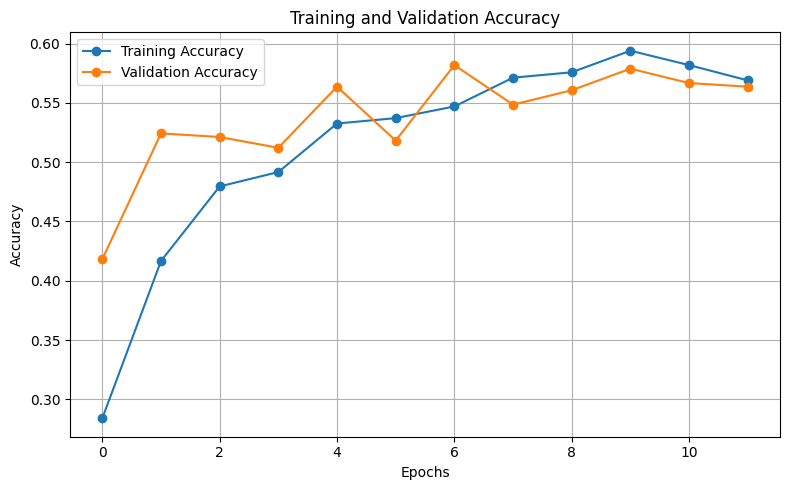

Save to:  /content/drive/MyDrive/MedicalExpert_Seminar_Outputs/training_validation_accuracy.png


In [24]:
#vẽ biểu đồ accuracy
plt.figure(figsize=(8, 5))

plt.plot(
    history_df["accuracy"],
    marker="o",
    label="Training Accuracy"
)
plt.plot(
    history_df["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.title("Training and Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()

accuracy_image_path = OUTPUT_DIR / "training_validation_accuracy.png"
plt.savefig(accuracy_image_path, dpi=300, bbox_inches="tight")
plt.show()

print("Save to: ", accuracy_image_path)

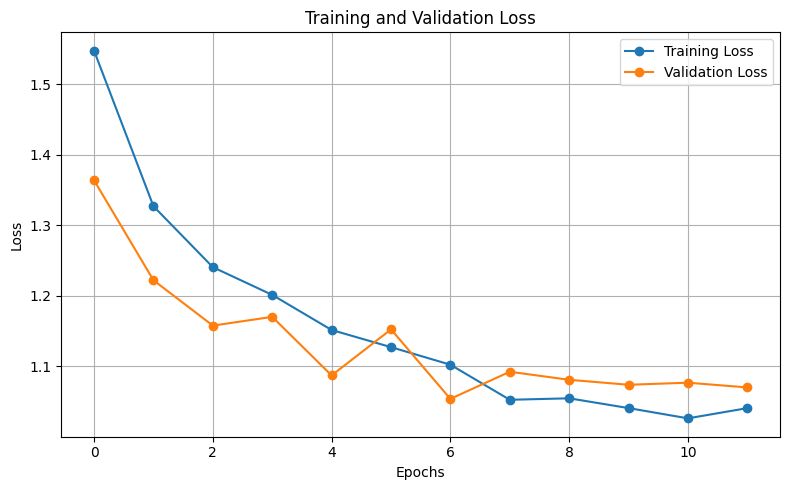

Save to:  /content/drive/MyDrive/MedicalExpert_Seminar_Outputs/training_validation_loss.png


In [25]:
#vẽ biểu đồ loss
plt.figure(figsize=(8, 5))

plt.plot(
    history_df["loss"],
    marker="o",
    label="Training Loss"
)
plt.plot(
    history_df["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.title("Training and Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()

loss_image_path = OUTPUT_DIR / "training_validation_loss.png"
plt.savefig(loss_image_path, dpi=300, bbox_inches="tight")
plt.show()

print("Save to: ", loss_image_path)

In [26]:
import math
import tensorflow as tf

print("===== KIỂM TRA TEST DATASET =====")

print("Số ảnh MedicalExpert-II ban đầu:", len(df_ii))
print("Số hash trùng giữa MedicalExpert-I và II:", len(duplicate_hashes))
print("Số ảnh test_df sau khi loại trùng:", len(test_df))

test_cardinality = tf.data.experimental.cardinality(test_ds).numpy()

print("Số batch trong test_ds:", test_cardinality)

if len(test_df) == 0:
    print("\ntest_df đang rỗng.")
    print("Không thể evaluate mô hình.")
elif test_cardinality == 0:
    print("\ntest_ds không có batch dữ liệu.")
    print("Cần tạo lại test_ds.")
else:
    print("\ntest_ds hợp lệ. Có thể evaluate.")

===== KIỂM TRA TEST DATASET =====
Số ảnh MedicalExpert-II ban đầu: 1650
Số hash trùng giữa MedicalExpert-I và II: 1633
Số ảnh test_df sau khi loại trùng: 0
Số batch trong test_ds: 0

test_df đang rỗng.
Không thể evaluate mô hình.


In [ ]:
# #load mô hình tốt nhất và evaluate
# best_model = keras.models.load_model(BEST_MODEL_PATH)

# test_loss, test_accuracy = best_model.evaluate(
#     test_ds,
#     verbose=1
# )

# print(f"Test Loss on MedicalExpert-II: {test_loss:.4f}")
# print(f"Test Accuracy on MedicalExpert-II: {test_accuracy:.4f}")
#Phương án này không được do sau khi lọc trùng bị rỗng

In [27]:
#combine the two datasets
df_combined = pd.concat(
    [df_i, df_ii],
    ignore_index=True
)

print("Combined dataset size: ", len(df_combined))
print("MedicalExpert-I images", len(df_i))
print("MedicalExpert-II images", len(df_ii))

Combined dataset size:  3300
MedicalExpert-I images 1650
MedicalExpert-II images 1650


In [28]:
#calculate mad5 hashes
def calculate_md5(filepath: str) -> str:
  md5_hash = hashlib.md5()

  with open(filepath, "rb") as file:
    for chunk in iter(lambda: file.read(4096), b""):
      md5_hash.update(chunk)

  return md5_hash.hexdigest()

if "hash" not in df_combined.columns:
  print("Calculating MD5 hashes...")

  df_combined["hash"] = (
      df_combined["filepath"].apply(calculate_md5)
  )

print("Total files:", len(df_combined))
print("Unique image contents: ", df_combined["hash"].nunique)

Total files: 3300
Unique image contents:  <bound method IndexOpsMixin.nunique of 0       966fb4c02a97c3ffb89f91a98e22437f
1       1af13c5538c1ab5597db6ad72b61e463
2       e9305b8cbbd5ccb7cd894762124e803b
3       dfc4994e51039c9fb4d960c706865c2d
4       0156aac54417d9c793356c816324016c
                      ...               
3295    fee2e4b2e5326ced66c04521216e82b2
3296    6d2b113abd969df73e856e449a1b3a29
3297    99e841cae183216387d22e616ca5a0d5
3298    6121c0ebbe2fec36317879752d46641c
3299    46217cbc99e1241c5b9399fff9cc1ac1
Name: hash, Length: 3300, dtype: object>


In [30]:
# Detect images that have conflicting labels
label_counts_by_hash = (
    df_combined
    .groupby("hash")["label"]
    .nunique()
)

conflicting_hashes = set(
    label_counts_by_hash[label_counts_by_hash > 1].index
)

print("Number of images with conflicting labels:", len(conflicting_hashes))

if len(conflicting_hashes) > 0:
    conflict_df = (
        df_combined[df_combined["hash"].isin(conflicting_hashes)]
        .sort_values(by=["hash", "dataset", "label"])
    )

    display(
        conflict_df[
            [
                "hash",
                "dataset",
                "filename",
                "class_name",
                "label",
                "filepath"
            ]
        ].head(30)
    )
else:
    print("No conflicting labels found.")

Number of images with conflicting labels: 11


,hash,dataset,filename,class_name,label,filepath
384,14f7bed4c7396a32c3408341f4d6dfa2,MedicalExpert-I,NormalG0 (445).png,0Normal,0,/content/drive/MyDrive/Digital_Knee_X_ray_Imag...
2608,14f7bed4c7396a32c3408341f4d6dfa2,MedicalExpert-II,DoubtfulG1 (7).png,1Doubtful,1,/content/drive/MyDrive/Digital_Knee_X_ray_Imag...
310,371a416f3477bbd8267c6c4e483be2ce,MedicalExpert-I,NormalG0 (379).png,0Normal,0,/content/drive/MyDrive/Digital_Knee_X_ray_Imag...
2375,371a416f3477bbd8267c6c4e483be2ce,MedicalExpert-II,DoubtfulG1 (3).png,1Doubtful,1,/content/drive/MyDrive/Digital_Knee_X_ray_Imag...
425,37aa8f8c31cf527eb6030b48a282a3e0,MedicalExpert-I,NormalG0 (482).png,0Normal,0,/content/drive/MyDrive/Digital_Knee_X_ray_Imag...
2582,37aa8f8c31cf527eb6030b48a282a3e0,MedicalExpert-II,DoubtfulG1 (486).png,1Doubtful,1,/content/drive/MyDrive/Digital_Knee_X_ray_Imag...
440,43ec170c88eb873cad37e6354438ec80,MedicalExpert-I,NormalG0 (496).png,0Normal,0,/content/drive/MyDrive/Digital_Knee_X_ray_Imag...
2583,43ec170c88eb873cad37e6354438ec80,MedicalExpert-II,DoubtfulG1 (487).png,1Doubtful,1,/content/drive/MyDrive/Digital_Knee_X_ray_Imag...
323,4d36306fc5d4fa0cebd909ba84f8a77f,MedicalExpert-I,NormalG0 (390).png,0Normal,0,/content/drive/MyDrive/Digital_Knee_X_ray_Imag...
2586,4d36306fc5d4fa0cebd909ba84f8a77f,MedicalExpert-II,DoubtfulG1 (5).png,1Doubtful,1,/content/drive/MyDrive/Digital_Knee_X_ray_Imag...


In [31]:
#build clean dataset
df_clean = (
    df_combined[
        ~df_combined["hash"].isin(conflicting_hashes)
    ]
    .drop_duplicates(
        subset=["hash"],
        keep="first"
    )
    .reset_index(drop=True)
)

print("---- Cleaning results ----")
print("Original number of files: ", len(df_combined))
print("Unique clean images: ", len(df_clean))
print("Remove files: ", len(df_combined) - len(df_clean))

clean_distribution = (
    df_clean["class_name"]
    .value_counts()
    .reindex(CLASS_NAMES)
    .fillna(0)
    .astype(int)
    .rename("Number of Images")
)

display(clean_distribution)

---- Cleaning results ----
Original number of files:  3300
Unique clean images:  1622
Remove files:  1678


,Number of Images
class_name,
0Normal,502
1Doubtful,474
2Mild,227
3Moderate,213
4Severe,206


In [32]:
#split the clean dataset
from sklearn.model_selection import train_test_split

train_df, tem_df = train_test_split(
    df_clean,
    test_size=0.3,
    random_state=SEED,
    stratify=df_clean["label"]
)

val_df, test_df = train_test_split(
    tem_df,
    test_size=0.5,
    random_state=SEED,
    stratify=tem_df["label"]
)

print("---- Dataset Spilt Results ----")
print("Training size: ", len(train_df))
print("Validation size: ", len(val_df))
print("Testing images: ", len(test_df))
print("Total: ", len(train_df) + len(val_df) + len(test_df))

---- Dataset Spilt Results ----
Training size:  1135
Validation size:  243
Testing images:  244
Total:  1622


In [33]:
#Verify that no data leakage remains

train_hashes = set(train_df["hash"])
val_hashes = set(val_df["hash"])
test_hashes = set(test_df["hash"])

train_val_overlap = len(
    train_hashes.intersection(val_hashes)
)

train_test_overlap = len(
    train_hashes.intersection(test_hashes)
)

val_test_overlap = len(
    val_hashes.intersection(test_hashes)
)

print("===== DATA LEAKAGE CHECK =====")
print("Train ∩ Validation:", train_val_overlap)
print("Train ∩ Test:", train_test_overlap)
print("Validation ∩ Test:", val_test_overlap)

assert train_val_overlap == 0
assert train_test_overlap == 0
assert val_test_overlap == 0

print("No duplicate images remain across Train, Validation, and Test sets.")

===== DATA LEAKAGE CHECK =====
Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0
No duplicate images remain across Train, Validation, and Test sets.


In [34]:
#Define the image preprocessing pipeline
AUTOTUNE = tf.data.AUTOTUNE

def load_and_preprocess_image(filepath, label):
    image = tf.io.read_file(filepath)

    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image.set_shape([None, None, 3])

    image = tf.image.resize(
        image,
        IMG_SIZE
    )

    image = tf.cast(
        image,
        tf.float32
    )

    return image, label


def create_tf_dataset(
    dataframe: pd.DataFrame,
    training: bool = False
):
    if len(dataframe) == 0:
        raise ValueError(
            "The DataFrame is empty. "
            "A TensorFlow dataset cannot be created."
        )

    filepaths = dataframe[
        "filepath"
    ].values

    labels = dataframe[
        "label"
    ].values.astype(np.int32)

    dataset = tf.data.Dataset.from_tensor_slices(
        (filepaths, labels)
    )

    if training:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    dataset = dataset.map(
        load_and_preprocess_image,
        num_parallel_calls=AUTOTUNE
    )

    dataset = dataset.batch(
        BATCH_SIZE,
        drop_remainder=False
    )

    dataset = dataset.prefetch(
        AUTOTUNE
    )

    return dataset

In [36]:
#Recreate Train, Validation, and Test datasets
train_ds = create_tf_dataset(
    train_df,
    training=True
)

val_ds = create_tf_dataset(
    val_df,
    training=False
)

test_ds = create_tf_dataset(
    test_df,
    training=False
)

train_batches = tf.data.experimental.cardinality(
    train_ds
).numpy()

val_batches = tf.data.experimental.cardinality(
    val_ds
).numpy()

test_batches = tf.data.experimental.cardinality(
    test_ds
).numpy()

print("===== TENSORFLOW DATASETS =====")
print("Training batches:", train_batches)
print("Validation batches:", val_batches)
print("Testing batches:", test_batches)

assert train_batches > 0
assert val_batches > 0
assert test_batches > 0

print("TensorFlow datasets were recreated successfully.")

===== TENSORFLOW DATASETS =====
Training batches: 36
Validation batches: 8
Testing batches: 8
TensorFlow datasets were recreated successfully.


In [37]:
#Inspect one testing batch

for images, labels in test_ds.take(1):
    print("===== TEST BATCH SAMPLE =====")
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)
    print("Minimum pixel value:", tf.reduce_min(images).numpy())
    print("Maximum pixel value:", tf.reduce_max(images).numpy())

===== TEST BATCH SAMPLE =====
Images shape: (32, 224, 244, 3)
Labels shape: (32,)
Minimum pixel value: 0.0
Maximum pixel value: 255.0


In [38]:
#Compute class weights from the clean training set

from sklearn.utils.class_weight import compute_class_weight

train_labels = train_df[
    "label"
].values

classes = np.unique(
    train_labels
)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_labels
)

class_weights = {
    int(class_id): float(weight)
    for class_id, weight in zip(
        classes,
        weights
    )
}

print("===== CLASS WEIGHTS =====")

for class_id, weight in class_weights.items():
    print(
        f"{CLASS_DISPLAY_NAMES[class_id]}: "
        f"{weight:.4f}"
    )

===== CLASS WEIGHTS =====
KL 0 - Normal: 0.6467
KL 1 - Doubtful: 0.6837
KL 2 - Mild: 1.4277
KL 3 - Moderate: 1.5235
KL 4 - Severe: 1.5764


In [39]:
#Recreate EfficientNetB0

base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(
        IMG_SIZE[0],
        IMG_SIZE[1],
        3
    )
)

base_model.trainable = False

inputs = keras.Input(
    shape=(
        IMG_SIZE[0],
        IMG_SIZE[1],
        3
    ),
    name="knee_xray_input"
)

x = data_augmentation(
    inputs
)

x = base_model(
    x,
    training=False
)

x = layers.GlobalAveragePooling2D(
    name="global_average_pooling"
)(x)

x = layers.Dropout(
    rate=0.30,
    name="dropout"
)(x)

outputs = layers.Dense(
    units=NUM_CLASSES,
    activation="softmax",
    name="kl_grade_output"
)(x)

model = keras.Model(
    inputs=inputs,
    outputs=outputs,
    name="EfficientNetB0_Clean_KL_Classifier"
)

model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=LEARNING_RATE
    ),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

model.summary()

Model: "EfficientNetB0_Clean_KL_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ knee_xray_input (InputLayer)    │ (None, 224, 244, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 244, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 8, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ kl_grade_output (Dense)         │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,055,976 (15.47 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [40]:
#Save the clean checkpoint separately

BEST_MODEL_PATH = (
    OUTPUT_DIR /
    "best_efficientnetb0_clean_unique_images.keras"
)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=str(BEST_MODEL_PATH),
        monitor="val_loss",
        save_best_only=True,
        mode="min",
        verbose=1
    ),

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        mode="min",
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-6,
        mode="min",
        verbose=1
    )
]

In [41]:
#Retrain the model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 0.2577 - loss: 1.6361
Epoch 1: val_loss improved from None to 1.31005, saving model to /content/drive/MyDrive/MedicalExpert_Seminar_Outputs/best_efficientnetb0_clean_unique_images.keras

Epoch 1: finished saving model to /content/drive/MyDrive/MedicalExpert_Seminar_Outputs/best_efficientnetb0_clean_unique_images.keras
36/36 ━━━━━━━━━━━━━━━━━━━━ 21s 323ms/step - accuracy: 0.2890 - loss: 1.5462 - val_accuracy: 0.5021 - val_loss: 1.3101 - learning_rate: 0.0010
Epoch 2/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.4195 - loss: 1.3703
Epoch 2: val_loss improved from 1.31005 to 1.21786, saving model to /content/drive/MyDrive/MedicalExpert_Seminar_Outputs/best_efficientnetb0_clean_unique_images.keras

Epoch 2: finished saving model to /content/drive/MyDrive/MedicalExpert_Seminar_Outputs/best_efficientnetb0_clean_unique_images.keras
36/36 ━━━━━━━━━━━━━━━━━━━━ 9s 240ms/step - accuracy: 0.4211 - loss: 1.3328 - val_accura

In [42]:
#Final validation before evaluation

print("===== FINAL TEST CHECK =====")

print("Testing images:", len(test_df))

test_batches = tf.data.experimental.cardinality(
    test_ds
).numpy()

print("Testing batches:", test_batches)

assert len(test_df) > 0
assert test_batches > 0

for images, labels in test_ds.take(1):
    print("First test batch image shape:", images.shape)
    print("First test batch label shape:", labels.shape)

print("The clean test dataset is ready for evaluation.")

===== FINAL TEST CHECK =====
Testing images: 244
Testing batches: 8
First test batch image shape: (32, 224, 244, 3)
First test batch label shape: (32,)
The clean test dataset is ready for evaluation.


In [43]:
#Evaluate the best model

best_model = keras.models.load_model(
    BEST_MODEL_PATH
)

test_loss, test_accuracy = best_model.evaluate(
    test_ds,
    verbose=1
)

print("\n===== CLEAN TEST RESULTS =====")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 182ms/step - accuracy: 0.5574 - loss: 1.0946

===== CLEAN TEST RESULTS =====
Test Loss: 1.0946
Test Accuracy: 0.5574


In [44]:
#Generate predictions

y_true = test_df[
    "label"
].values.astype(np.int32)

y_probability = best_model.predict(
    test_ds,
    verbose=1
)

y_pred = np.argmax(
    y_probability,
    axis=1
)

print("===== PREDICTION SHAPES =====")
print("True labels:", y_true.shape)
print("Predicted labels:", y_pred.shape)
print("Prediction probabilities:", y_probability.shape)

assert len(y_true) == len(y_pred)

print("Predictions were generated successfully.")

8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 524ms/step
===== PREDICTION SHAPES =====
True labels: (244,)
Predicted labels: (244,)
Prediction probabilities: (244, 5)
Predictions were generated successfully.


In [45]:
#Accuracy, Macro F1-score, and Quadratic Weighted Kappa
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    cohen_kappa_score
)

accuracy = accuracy_score(
    y_true,
    y_pred
)

macro_f1 = f1_score(
    y_true,
    y_pred,
    average="macro"
)

qwk = cohen_kappa_score(
    y_true,
    y_pred,
    weights="quadratic"
)

metrics_summary = pd.DataFrame({
    "Metric": [
        "Test Loss",
        "Test Accuracy",
        "Macro F1-score",
        "Quadratic Weighted Kappa"
    ],
    "Value": [
        test_loss,
        accuracy,
        macro_f1,
        qwk
    ]
})

display(metrics_summary)

metrics_path = (
    OUTPUT_DIR /
    "evaluation_summary_clean_test.csv"
)

metrics_summary.to_csv(
    metrics_path,
    index=False,
    encoding="utf-8-sig"
)

print("Saved evaluation summary to:", metrics_path)

,Metric,Value
0,Test Loss,1.094621
1,Test Accuracy,0.557377
2,Macro F1-score,0.500965
3,Quadratic Weighted Kappa,0.668709


Saved evaluation summary to: /content/drive/MyDrive/MedicalExpert_Seminar_Outputs/evaluation_summary_clean_test.csv


In [46]:
#Generate the per-class report

from sklearn.metrics import classification_report

report_dict = classification_report(
    y_true,
    y_pred,
    labels=list(range(NUM_CLASSES)),
    target_names=CLASS_DISPLAY_NAMES,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(
    report_dict
).transpose()

display(report_df)

report_path = (
    OUTPUT_DIR /
    "classification_report_clean_test.csv"
)

report_df.to_csv(
    report_path,
    encoding="utf-8-sig"
)

print("Saved classification report to:", report_path)

,precision,recall,f1-score,support
KL 0 - Normal,0.572816,0.776316,0.659218,76.000000
KL 1 - Doubtful,0.513889,0.521127,0.517483,71.000000
KL 2 - Mild,0.222222,0.058824,0.093023,34.000000
KL 3 - Moderate,0.564103,0.687500,0.619718,32.000000
KL 4 - Severe,0.761905,0.516129,0.615385,31.000000
accuracy,0.557377,0.557377,0.557377,0.557377
macro avg,0.526987,0.511979,0.500965,244.000000
weighted avg,0.529697,0.557377,0.528330,244.000000


Saved classification report to: /content/drive/MyDrive/MedicalExpert_Seminar_Outputs/classification_report_clean_test.csv


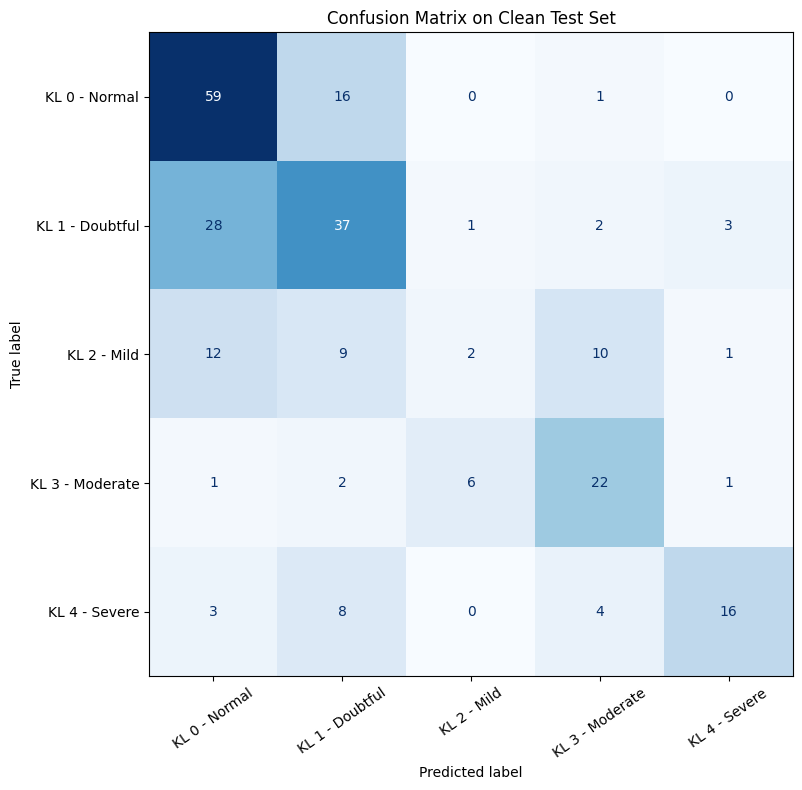

Saved confusion matrix to: /content/drive/MyDrive/MedicalExpert_Seminar_Outputs/confusion_matrix_clean_test.png


In [47]:
#Plot the confusion matrix
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=list(range(NUM_CLASSES))
)

fig, ax = plt.subplots(
    figsize=(9, 8)
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=CLASS_DISPLAY_NAMES
)

disp.plot(
    ax=ax,
    cmap="Blues",
    xticks_rotation=35,
    values_format="d",
    colorbar=False
)

plt.title(
    "Confusion Matrix on Clean Test Set"
)

plt.tight_layout()

cm_path = (
    OUTPUT_DIR /
    "confusion_matrix_clean_test.png"
)

plt.savefig(
    cm_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved confusion matrix to:", cm_path)

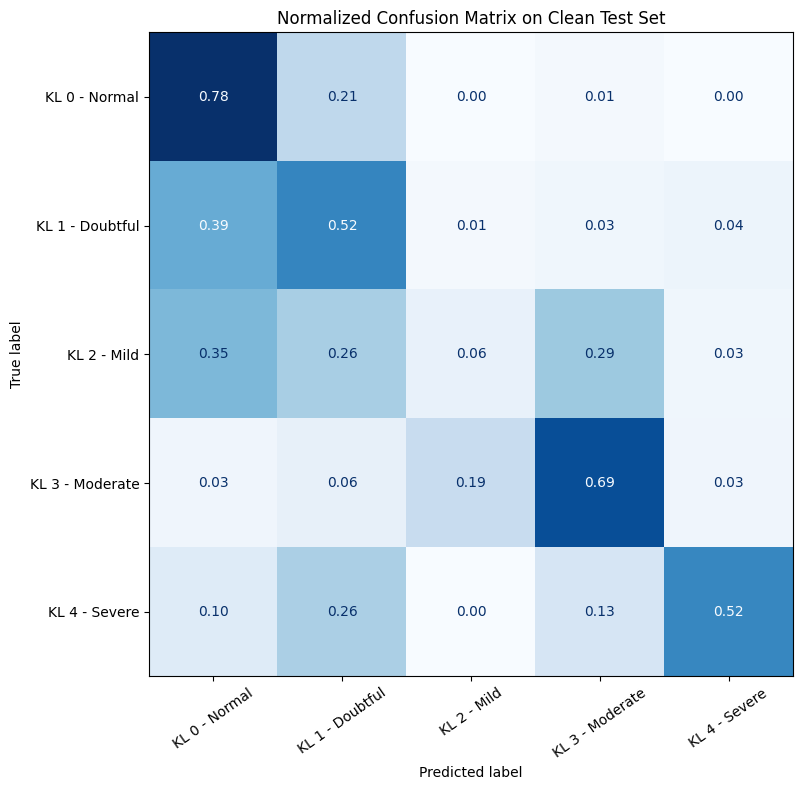

Saved normalized confusion matrix to: /content/drive/MyDrive/MedicalExpert_Seminar_Outputs/confusion_matrix_clean_test_normalized.png


In [48]:
# Plot the normalized confusion matrix
cm_normalized = confusion_matrix(
    y_true,
    y_pred,
    labels=list(range(NUM_CLASSES)),
    normalize="true"
)

fig, ax = plt.subplots(
    figsize=(9, 8)
)

disp_normalized = ConfusionMatrixDisplay(
    confusion_matrix=cm_normalized,
    display_labels=CLASS_DISPLAY_NAMES
)

disp_normalized.plot(
    ax=ax,
    cmap="Blues",
    xticks_rotation=35,
    values_format=".2f",
    colorbar=False
)

plt.title(
    "Normalized Confusion Matrix on Clean Test Set"
)

plt.tight_layout()

cm_normalized_path = (
    OUTPUT_DIR /
    "confusion_matrix_clean_test_normalized.png"
)

plt.savefig(
    cm_normalized_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved normalized confusion matrix to:",
    cm_normalized_path
)